# Loading and Cleaning the Dataset

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [66]:
df = pd.read_csv("/home/kevin/air_quality_intern/air_quality_project/data/raw/IQAir_validated_ICRAF.csv")

In [67]:
df.head()

,Source,Device timezone,Datetime_start(UTC),Datetime_end(UTC),AQI US,AQI CN,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),...,slot.4.co2,slot.4.pm1,slot.4.pm10,slot.4.pm25,slot.4.pc,slot.4.voc,slot.4.hcho,slot.4.o3,slot.4.co,slot.4.no2
0,2hc1epd8gfq,Africa/Nairobi UTC+03:00,12/31/2024 21:00,12/31/2024 21:59,73,30,21,34,16,420,...,NaN,17,33,21,1967,NaN,NaN,NaN,NaN,NaN
1,2hc1epd8gfq,Africa/Nairobi UTC+03:00,12/31/2024 22:00,12/31/2024 22:59,71,29,20,31,15,421,...,NaN,15,30,20,1745,NaN,NaN,NaN,NaN,NaN
2,2hc1epd8gfq,Africa/Nairobi UTC+03:00,12/31/2024 23:00,12/31/2024 23:59,68,26,18,29,14,420,...,NaN,14,28,18,1599,NaN,NaN,NaN,NaN,NaN
3,2hc1epd8gfq,Africa/Nairobi UTC+03:00,01/01/2025 00:00,01/01/2025 00:59,64,23,16,27,13,420,...,NaN,13,26,16,1469,NaN,NaN,NaN,NaN,NaN
4,2hc1epd8gfq,Africa/Nairobi UTC+03:00,01/01/2025 01:00,01/01/2025 01:59,68,26,18,29,14,429,...,NaN,14,28,18,1657,NaN,NaN,NaN,NaN,NaN


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8713 entries, 0 to 8712
Data columns (total 64 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Source                    8713 non-null   str    
 1   Device timezone           8713 non-null   str    
 2   Datetime_start(UTC)       8713 non-null   str    
 3   Datetime_end(UTC)         8713 non-null   str    
 4   AQI US                    8713 non-null   int64  
 5   AQI CN                    8713 non-null   int64  
 6   PM2.5 (ug/m3)             8713 non-null   int64  
 7   PM10 (ug/m3)              8713 non-null   int64  
 8   PM1 (ug/m3)               8713 non-null   int64  
 9   CO2 (ppm)                 8713 non-null   int64  
 10  CO (ug/m3)                0 non-null      float64
 11  TVOC (index)              0 non-null      float64
 12  NOx (index)               0 non-null      float64
 13  O3 (ug/m3)                0 non-null      float64
 14  NO2 (ug/m3)        

In [69]:
# describe() gives a statistical summary of the Data. Mean, std, min,max values and quartiles.
# This is useful to understand the distribution of the data and identify any potential outliers or anomalies.
df.describe()

,AQI US,AQI CN,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),CO (ug/m3),TVOC (index),NOx (index),O3 (ug/m3),...,slot.4.co2,slot.4.pm1,slot.4.pm10,slot.4.pm25,slot.4.pc,slot.4.voc,slot.4.hcho,slot.4.o3,slot.4.co,slot.4.no2
count,8713.000000,8713.000000,8713.000000,8713.000000,8713.000000,8713.000000,0.0,0.0,0.0,0.0,...,0.0,8713.000000,8713.000000,8713.000000,8713.000000,0.0,0.0,0.0,0.0,0.0
mean,55.192815,19.119591,13.391599,20.969815,10.395157,420.772180,NaN,NaN,NaN,NaN,...,NaN,10.606221,20.668656,13.415930,56913.088948,NaN,NaN,NaN,NaN,NaN
std,20.335563,11.416701,8.047208,12.393648,6.114687,17.035582,NaN,NaN,NaN,NaN,...,NaN,6.344668,12.429158,8.073786,44726.774741,NaN,NaN,NaN,NaN,NaN
min,6.000000,1.000000,1.000000,2.000000,1.000000,398.000000,NaN,NaN,NaN,NaN,...,NaN,1.000000,2.000000,1.000000,247.000000,NaN,NaN,NaN,NaN,NaN
25%,44.000000,11.000000,8.000000,12.000000,6.000000,409.000000,NaN,NaN,NaN,NaN,...,NaN,6.000000,12.000000,8.000000,27911.000000,NaN,NaN,NaN,NaN,NaN
50%,56.000000,17.000000,12.000000,19.000000,10.000000,417.000000,NaN,NaN,NaN,NaN,...,NaN,10.000000,18.000000,12.000000,49416.000000,NaN,NaN,NaN,NaN,NaN
75%,66.000000,24.000000,17.000000,27.000000,14.000000,427.000000,NaN,NaN,NaN,NaN,...,NaN,14.000000,27.000000,17.000000,76885.000000,NaN,NaN,NaN,NaN,NaN
max,168.000000,107.000000,80.000000,125.000000,62.000000,534.000000,NaN,NaN,NaN,NaN,...,NaN,62.000000,125.000000,80.000000,461968.000000,NaN,NaN,NaN,NaN,NaN


            AQI US       AQI CN  PM2.5 (ug/m3)  PM10 (ug/m3)  PM1 (ug/m3)  \
count  8713.000000  8713.000000    8713.000000   8713.000000  8713.000000   
mean     55.192815    19.119591      13.391599     20.969815    10.395157   
std      20.335563    11.416701       8.047208     12.393648     6.114687   
min       6.000000     1.000000       1.000000      2.000000     1.000000   
25%      44.000000    11.000000       8.000000     12.000000     6.000000   
50%      56.000000    17.000000      12.000000     19.000000    10.000000   
75%      66.000000    24.000000      17.000000     27.000000    14.000000   
max     168.000000   107.000000      80.000000    125.000000    62.000000   

         CO2 (ppm)  CO (ug/m3)  TVOC (index)  NOx (index)  O3 (ug/m3)  ...  \
count  8713.000000         0.0           0.0          0.0         0.0  ...   
mean    420.772180         NaN           NaN          NaN         NaN  ...   
std      17.035582         NaN           NaN          NaN         NaN  .

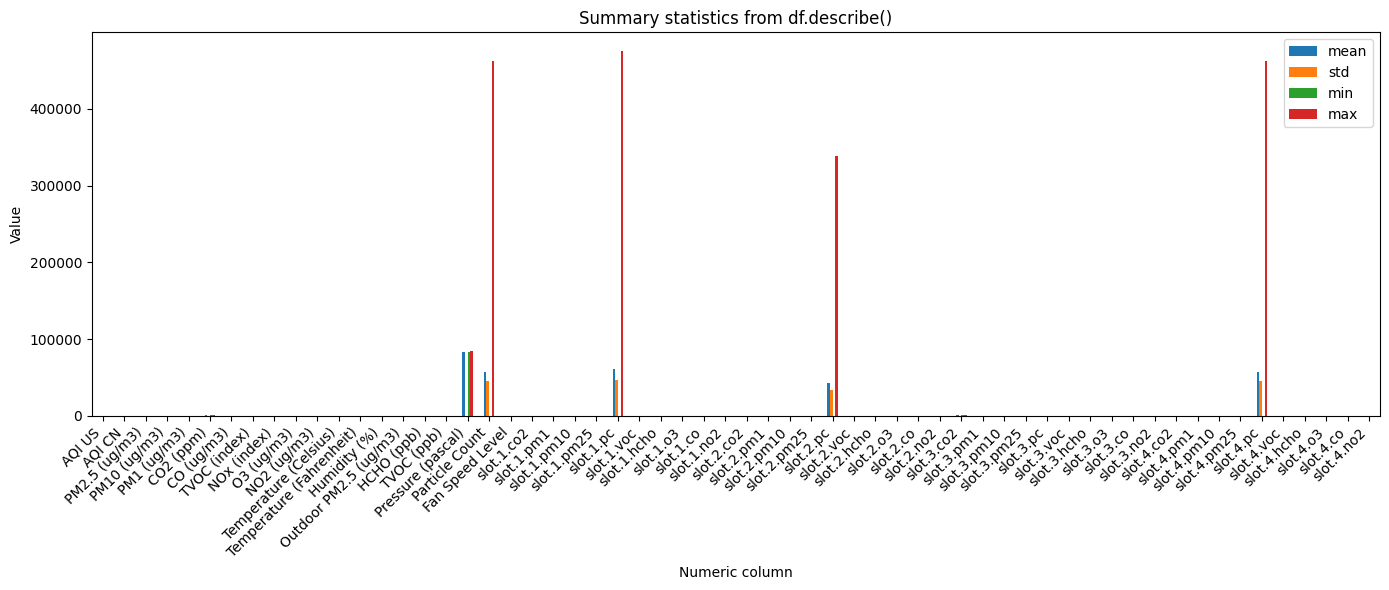

In [70]:
# Plotting summary statistics from df.describe()
desc = df.describe()
print(desc)

desc_T = desc.T
selected_stats = ['mean', 'std', 'min', 'max']
desc_T[selected_stats].plot(kind='bar', figsize=(14, 6))
plt.title('Summary statistics from df.describe()')
plt.xlabel('Numeric column')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [71]:
# Remove columns that are completely empty (all NaN values)
#axis = 1 means we are looking at columns, how='all' means we drop columns where all values are NaN
df = df.dropna(axis=1, how='all')

In [72]:
df.head()

,Source,Device timezone,Datetime_start(UTC),Datetime_end(UTC),AQI US,AQI CN,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),...,slot.1.pc,slot.2.pm1,slot.2.pm10,slot.2.pm25,slot.2.pc,slot.3.co2,slot.4.pm1,slot.4.pm10,slot.4.pm25,slot.4.pc
0,2hc1epd8gfq,Africa/Nairobi UTC+03:00,12/31/2024 21:00,12/31/2024 21:59,73,30,21,34,16,420,...,2200,14,32,19,1656,420,17,33,21,1967
1,2hc1epd8gfq,Africa/Nairobi UTC+03:00,12/31/2024 22:00,12/31/2024 22:59,71,29,20,31,15,421,...,1930,13,30,18,1473,421,15,30,20,1745
2,2hc1epd8gfq,Africa/Nairobi UTC+03:00,12/31/2024 23:00,12/31/2024 23:59,68,26,18,29,14,420,...,1768,12,27,16,1343,420,14,28,18,1599
3,2hc1epd8gfq,Africa/Nairobi UTC+03:00,01/01/2025 00:00,01/01/2025 00:59,64,23,16,27,13,420,...,1652,11,26,15,1247,420,13,26,16,1469
4,2hc1epd8gfq,Africa/Nairobi UTC+03:00,01/01/2025 01:00,01/01/2025 01:59,68,26,18,29,14,429,...,1841,12,28,17,1406,429,14,28,18,1657


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8713 entries, 0 to 8712
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Source                    8713 non-null   str    
 1   Device timezone           8713 non-null   str    
 2   Datetime_start(UTC)       8713 non-null   str    
 3   Datetime_end(UTC)         8713 non-null   str    
 4   AQI US                    8713 non-null   int64  
 5   AQI CN                    8713 non-null   int64  
 6   PM2.5 (ug/m3)             8713 non-null   int64  
 7   PM10 (ug/m3)              8713 non-null   int64  
 8   PM1 (ug/m3)               8713 non-null   int64  
 9   CO2 (ppm)                 8713 non-null   int64  
 10  Temperature (Celsius)     8713 non-null   int64  
 11  Temperature (Fahrenheit)  8713 non-null   float64
 12  Humidity (%)              8713 non-null   int64  
 13  Pressure (pascal)         8713 non-null   int64  
 14  Particle Count     

In [74]:
#checking for missing values in each column
df.isnull().sum()

Source                      0
Device timezone             0
Datetime_start(UTC)         0
Datetime_end(UTC)           0
AQI US                      0
AQI CN                      0
PM2.5 (ug/m3)               0
PM10 (ug/m3)                0
PM1 (ug/m3)                 0
CO2 (ppm)                   0
Temperature (Celsius)       0
Temperature (Fahrenheit)    0
Humidity (%)                0
Pressure (pascal)           0
Particle Count              0
slot.1.pm1                  0
slot.1.pm10                 0
slot.1.pm25                 0
slot.1.pc                   0
slot.2.pm1                  0
slot.2.pm10                 0
slot.2.pm25                 0
slot.2.pc                   0
slot.3.co2                  0
slot.4.pm1                  0
slot.4.pm10                 0
slot.4.pm25                 0
slot.4.pc                   0
dtype: int64

In [75]:
#checking for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [76]:
#check for duplictaed columns
df.columns.duplicated().sum()

np.int64(0)

In [77]:
#convert date columns to datetime format
df['Datetime_start(UTC)'] = pd.to_datetime(df['Datetime_start(UTC)'])
df['Datetime_end(UTC)'] = pd.to_datetime(df['Datetime_end(UTC)'])

In [78]:
#extract useful time features from the datetime columns
df['hour'] = df['Datetime_start(UTC)'].dt.hour

df['day'] = df['Datetime_start(UTC)'].dt.day

df['month'] = df['Datetime_start(UTC)'].dt.month

df['day_of_week'] = df['Datetime_start(UTC)'].dt.day_name()


In [79]:
#drop the fahrenheit column since we have the celsius column and it is redundant
df.drop(columns=['Temperature (Fahrenheit)'], inplace=True)

In [80]:
#lets check for outliers in the PM2.5 column using IQR method
Q1 = df['PM2.5 (ug/m3)'].quantile(0.25)
Q3 = df['PM2.5 (ug/m3)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['PM2.5 (ug/m3)'] < lower_bound) |
    (df['PM2.5 (ug/m3)'] > upper_bound)
]


In [81]:
#print the lower and upper bounds for PM2.5
print(f"Lower bound for PM2.5: {lower_bound}")
print(f"Upper bound for PM2.5: {upper_bound}")

Lower bound for PM2.5: -5.5
Upper bound for PM2.5: 30.5


In [82]:
#list the outliers in the lower and upper bound
print("Outliers below lower bound:")
print(outliers[outliers['PM2.5 (ug/m3)'] < lower_bound]['PM2.5 (ug/m3)'])
print("\nOutliers above upper bound:")
print(outliers[outliers['PM2.5 (ug/m3)'] > upper_bound]['PM2.5 (ug/m3)'])  

Outliers below lower bound:
Series([], Name: PM2.5 (ug/m3), dtype: int64)

Outliers above upper bound:
633     34
634     39
635     38
636     36
645     37
        ..
6932    33
6933    39
6934    34
7201    31
7510    31
Name: PM2.5 (ug/m3), Length: 330, dtype: int64


In [83]:
df.head()

,Source,Device timezone,Datetime_start(UTC),Datetime_end(UTC),AQI US,AQI CN,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),...,slot.2.pc,slot.3.co2,slot.4.pm1,slot.4.pm10,slot.4.pm25,slot.4.pc,hour,day,month,day_of_week
0,2hc1epd8gfq,Africa/Nairobi UTC+03:00,2024-12-31 21:00:00,2024-12-31 21:59:00,73,30,21,34,16,420,...,1656,420,17,33,21,1967,21,31,12,Tuesday
1,2hc1epd8gfq,Africa/Nairobi UTC+03:00,2024-12-31 22:00:00,2024-12-31 22:59:00,71,29,20,31,15,421,...,1473,421,15,30,20,1745,22,31,12,Tuesday
2,2hc1epd8gfq,Africa/Nairobi UTC+03:00,2024-12-31 23:00:00,2024-12-31 23:59:00,68,26,18,29,14,420,...,1343,420,14,28,18,1599,23,31,12,Tuesday
3,2hc1epd8gfq,Africa/Nairobi UTC+03:00,2025-01-01 00:00:00,2025-01-01 00:59:00,64,23,16,27,13,420,...,1247,420,13,26,16,1469,0,1,1,Wednesday
4,2hc1epd8gfq,Africa/Nairobi UTC+03:00,2025-01-01 01:00:00,2025-01-01 01:59:00,68,26,18,29,14,429,...,1406,429,14,28,18,1657,1,1,1,Wednesday


In [84]:
# Drop column: 'Device timezone'
df = df.drop(columns=['Device timezone'])

# Drop column: 'Datetime_start(UTC)'
df = df.drop(columns=['Datetime_start(UTC)'])

# Drop column: 'Datetime_end(UTC)'
df = df.drop(columns=['Datetime_end(UTC)'])

# Drop column: 'Source'
df = df.drop(columns=['Source'])

In [85]:
df.head()

,AQI US,AQI CN,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),Temperature (Celsius),Humidity (%),Pressure (pascal),Particle Count,...,slot.2.pc,slot.3.co2,slot.4.pm1,slot.4.pm10,slot.4.pm25,slot.4.pc,hour,day,month,day_of_week
0,73,30,21,34,16,420,22,68,83315,1967,...,1656,420,17,33,21,1967,21,31,12,Tuesday
1,71,29,20,31,15,421,21,69,83260,1745,...,1473,421,15,30,20,1745,22,31,12,Tuesday
2,68,26,18,29,14,420,21,69,83207,1599,...,1343,420,14,28,18,1599,23,31,12,Tuesday
3,64,23,16,27,13,420,21,70,83182,1469,...,1247,420,13,26,16,1469,0,1,1,Wednesday
4,68,26,18,29,14,429,21,71,83193,1657,...,1406,429,14,28,18,1657,1,1,1,Wednesday


In [86]:
df.to_csv("air_quality_cleaned.csv", index=False)

In [87]:
#find PM2.5 values btn 0 and 15 and don't print just tell me the number of values in that range

pm25_filtered = df[(df['PM2.5 (ug/m3)'] >= 0) & (df['PM2.5 (ug/m3)'] <= 15)]
print(len(pm25_filtered))


5893


# Calculate the Air Quality Index using PM2.5 data

In [88]:
#calculate the AQI for all PM2.5 values using the formula AQI = (PM2.5 / 15) * 50 and add it as a new column to the dataframe
df['AQI'] = (df['PM2.5 (ug/m3)'] / 15) * 50



In [89]:
df.head()

,AQI US,AQI CN,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),Temperature (Celsius),Humidity (%),Pressure (pascal),Particle Count,...,slot.3.co2,slot.4.pm1,slot.4.pm10,slot.4.pm25,slot.4.pc,hour,day,month,day_of_week,AQI
0,73,30,21,34,16,420,22,68,83315,1967,...,420,17,33,21,1967,21,31,12,Tuesday,70.000000
1,71,29,20,31,15,421,21,69,83260,1745,...,421,15,30,20,1745,22,31,12,Tuesday,66.666667
2,68,26,18,29,14,420,21,69,83207,1599,...,420,14,28,18,1599,23,31,12,Tuesday,60.000000
3,64,23,16,27,13,420,21,70,83182,1469,...,420,13,26,16,1469,0,1,1,Wednesday,53.333333
4,68,26,18,29,14,429,21,71,83193,1657,...,429,14,28,18,1657,1,1,1,Wednesday,60.000000


In [90]:
#lets remove the AQI US and AQI CN columns since we have the AQI column that we calculated and they are redundant
df.drop(columns=['AQI US', 'AQI CN'], inplace=True)


In [91]:
df.head()

,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),Temperature (Celsius),Humidity (%),Pressure (pascal),Particle Count,slot.1.pm1,slot.1.pm10,...,slot.3.co2,slot.4.pm1,slot.4.pm10,slot.4.pm25,slot.4.pc,hour,day,month,day_of_week,AQI
0,21,34,16,420,22,68,83315,1967,17,41,...,420,17,33,21,1967,21,31,12,Tuesday,70.000000
1,20,31,15,421,21,69,83260,1745,15,37,...,421,15,30,20,1745,22,31,12,Tuesday,66.666667
2,18,29,14,420,21,69,83207,1599,15,37,...,420,14,28,18,1599,23,31,12,Tuesday,60.000000
3,16,27,13,420,21,70,83182,1469,14,36,...,420,13,26,16,1469,0,1,1,Wednesday,53.333333
4,18,29,14,429,21,71,83193,1657,15,37,...,429,14,28,18,1657,1,1,1,Wednesday,60.000000


In [92]:
# 0-50 (Good): 0 to 15 µg/m³
#51-100 (Moderate): 15 to 30 µg/m³
#101-150 (Unhealthy for Sensitive Groups): 30 to 50 µg/m³
#151-200 (Unhealthy): 50 to 100 µg/m³
#201-300 (Very Unhealthy): 100 to 200 µg/m³
#301-500 (Hazardous): 200 to 500 µg/m³
# using these categories we can create a new column in the dataframe that categorizes the AQI values into categories.

bins = [0, 15, 30, 50, 100, 200, 500]
labels = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
df['AQI Category'] = pd.cut(df['AQI'], bins=bins, labels=labels, right=False)


In [93]:
df.head()

,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),Temperature (Celsius),Humidity (%),Pressure (pascal),Particle Count,slot.1.pm1,slot.1.pm10,...,slot.4.pm1,slot.4.pm10,slot.4.pm25,slot.4.pc,hour,day,month,day_of_week,AQI,AQI Category
0,21,34,16,420,22,68,83315,1967,17,41,...,17,33,21,1967,21,31,12,Tuesday,70.000000,Unhealthy
1,20,31,15,421,21,69,83260,1745,15,37,...,15,30,20,1745,22,31,12,Tuesday,66.666667,Unhealthy
2,18,29,14,420,21,69,83207,1599,15,37,...,14,28,18,1599,23,31,12,Tuesday,60.000000,Unhealthy
3,16,27,13,420,21,70,83182,1469,14,36,...,13,26,16,1469,0,1,1,Wednesday,53.333333,Unhealthy
4,18,29,14,429,21,71,83193,1657,15,37,...,14,28,18,1657,1,1,1,Wednesday,60.000000,Unhealthy


In [94]:
#search which day of the week had the "good" AQI values the most
good_aqi = df[df['AQI Category'] == 'Good']
good_aqi_by_day = good_aqi['day_of_week'].value_counts()
print(good_aqi_by_day)

day_of_week
Sunday       143
Wednesday    114
Monday        95
Tuesday       89
Saturday      87
Friday        82
Thursday      76
Name: count, dtype: int64


In [95]:
#search for which hour of the day had the "unhealthy" AQI values the most
unhealthy_aqi = df[df['AQI Category'] == 'Unhealthy']
unhealthy_aqi_by_hour = unhealthy_aqi['hour'].value_counts()
print(unhealthy_aqi_by_hour)

hour
18    180
4     176
5     173
19    170
17    163
20    141
6     140
16    139
3     138
7     123
21    119
8     114
2     112
1     101
9     101
22     99
10     93
15     90
23     88
0      86
11     74
13     74
14     73
12     71
Name: count, dtype: int64


In [96]:
#lets remove the columns with slot.*
columns_to_drop = [col for col in df.columns if col.startswith('slot.')]
df.drop(columns=columns_to_drop, inplace=True)


In [97]:
df.head()

,PM2.5 (ug/m3),PM10 (ug/m3),PM1 (ug/m3),CO2 (ppm),Temperature (Celsius),Humidity (%),Pressure (pascal),Particle Count,hour,day,month,day_of_week,AQI,AQI Category
0,21,34,16,420,22,68,83315,1967,21,31,12,Tuesday,70.000000,Unhealthy
1,20,31,15,421,21,69,83260,1745,22,31,12,Tuesday,66.666667,Unhealthy
2,18,29,14,420,21,69,83207,1599,23,31,12,Tuesday,60.000000,Unhealthy
3,16,27,13,420,21,70,83182,1469,0,1,1,Wednesday,53.333333,Unhealthy
4,18,29,14,429,21,71,83193,1657,1,1,1,Wednesday,60.000000,Unhealthy


# Analysis (Charts) -- Quality of Air using the AQI values

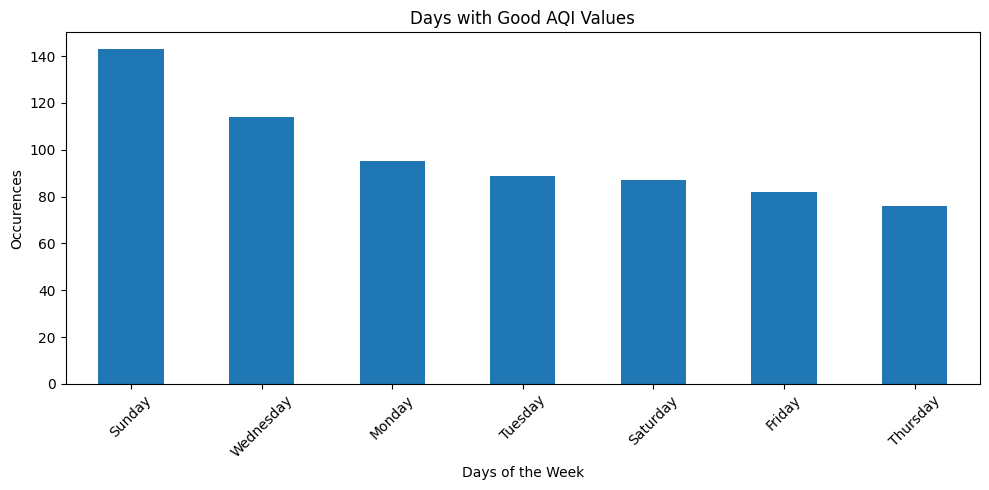

In [98]:
#lets create a chart showing the specific dayof the week with the most "good" AQI values
good_aqi_by_day = good_aqi['day_of_week'].value_counts()
good_aqi_by_day.plot(kind='bar', figsize=(10, 5))
plt.title('Days with Good AQI Values')
plt.xlabel('Days of the Week')
plt.ylabel('Occurences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


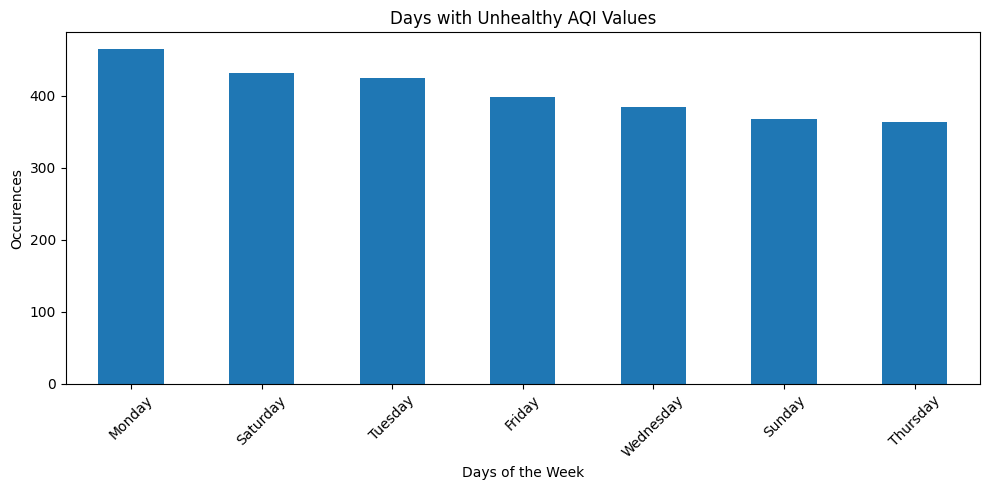

In [ ]:
#chart showing the days of the week with the average AQI values for the "unhealthy" AQI category
unhealthy_aqi_by_day = unhealthy_aqi['day_of_week'].value_counts()
unhealthy_aqi_by_day.plot(kind='bar', figsize=(10, 5))
plt.title('Days with Unhealthy AQI Values')
plt.xlabel('Days of the Week')
plt.ylabel('Occurences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

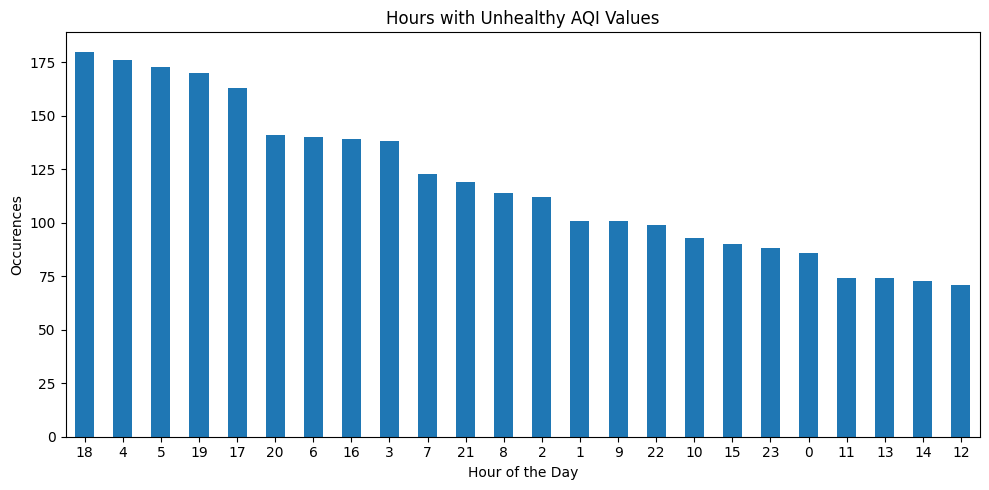

In [100]:
#hour of the day that had the "unhealthy" AQI value occurencences
unhealthy_aqi_by_hour = unhealthy_aqi['hour'].value_counts()
unhealthy_aqi_by_hour.plot(kind='bar', figsize=(10, 5))
plt.title('Hours with Unhealthy AQI Values')
plt.xlabel('Hour of the Day')
plt.ylabel('Occurences')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


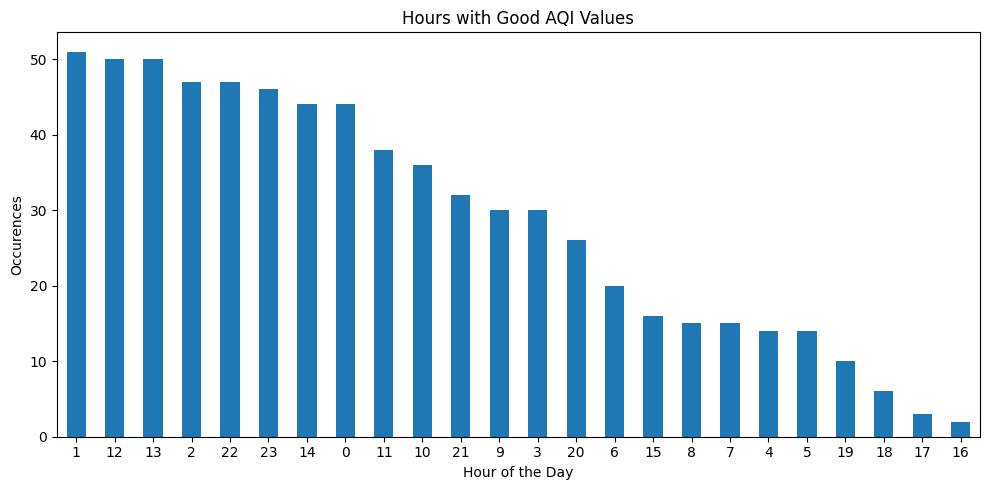

In [101]:
#hour of the day with the most "good" AQI values
good_aqi_by_hour = good_aqi['hour'].value_counts()
good_aqi_by_hour.plot(kind='bar', figsize=(10, 5))
plt.title('Hours with Good AQI Values')
plt.xlabel('Hour of the Day')
plt.ylabel('Occurences')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
#the last use dataframe into a csv file --> final_clean_dataset
df.to_csv("final_clean_dataset.csv", index=False)